# Exposure Time Calculator

`slicersim.lazuli_etc`: a top level function to quickly get the expected exposure time.

## Any spectrum

Provide a spectrum with good spectral resolution. 

The input flux could be in physical units (“flambda“: erg/s/cm2/A) and/or you can manually set the desired flux amplitude in a given band (e.g. 20mag in "sdssr").

Lazuli's spectrograph covered 4000 A to 17_000 A. Your input spectrum should cover at least that too.

In [1]:
import numpy as np
import slicersim

In [2]:
# fake flat spectrum
lbda = np.arange(3_000, 20_000, 0.5) # every 0.5A
flux = np.ones( lbda.shape )

Say you want the exposure time needed to obtained an average signal to noise ratio of 20
between 7000 A and 8000 A. And you want this target to have 21 mag in the “sdssr“ band.

In [11]:
%%time
exptime, target = slicersim.lazuli_etc(lbda, flux, 
                                       snr=20, lbda_range=[7000, 8000], 
                                       mag=23, band="sdssr")

CPU times: user 2.69 s, sys: 307 ms, total: 3 s
Wall time: 3.02 s


In [6]:
print(f"{exptime=} seconds")

exptime=588.64 seconds


## Access the realistic spectrum

In [14]:
lbda, flux_true, variance = target.get_spectrum(unit="flambda", incl_error=False)

/Users/rigault/miniforge3/envs/pearl/lib/python3.11/site-packages/slicersim/simulation.py:1131: RuntimeWarning: divide by zero encountered in divide
  coefs = 1 / (transmission * self.get_parameter("nramp"))


/var/folders/kt/dnsb_cyx445cbz2ht_3l2m6w00029p/T/ipykernel_72751/3945756414.py:9: RuntimeWarning: invalid value encountered in subtract
  flux-np.sqrt(variance), alpha=0.2)


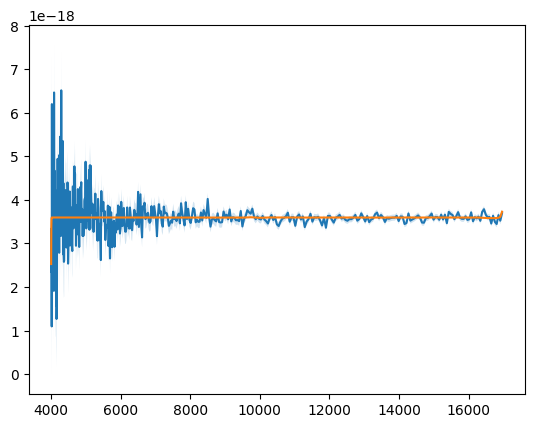

In [16]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

ax.plot(lbda, flux)
ax.plot(lbda, flux_true)
ax.fill_between(lbda, 
                flux+np.sqrt(variance), 
                flux-np.sqrt(variance), alpha=0.2)

## Type Ia Supernovae

Lazuli's spectrograph primary aims at targeting Type Ia Supernovae (SN Ia). 

There is a wrapper of the Lazuli object that enables you to get a realist SN Ia given its properties, such as the SALT stretch (x1), color (c) and redshift.

Say we want an average signal to noise of 15 in the rest-frame 6000A to 7000A

In [17]:
exptime, this_snia = slicersim.lazuli_sn_etc("salt", 
                                             redshift=1.2, c=0.2, x1=-0.5, 
                                             snr=20, lbda_range=[6000, 7000], 
                                             frame="rest")
exptime_h = exptime / 3600

In [18]:
print(f"{exptime_h=:.1f} hours")

exptime_h=6.4 hours


In [19]:
lbda, flux, variance = this_snia.get_spectrum(unit="flambda")

/var/folders/kt/dnsb_cyx445cbz2ht_3l2m6w00029p/T/ipykernel_72751/2515771784.py:7: RuntimeWarning: invalid value encountered in add
  flux+np.sqrt(variance),


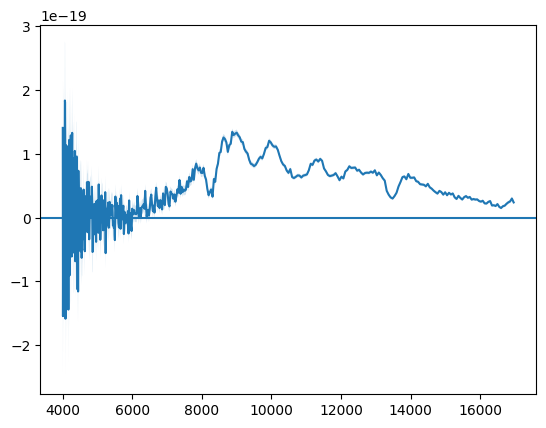

In [20]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

ax.plot(lbda, flux)
ax.fill_between(lbda, 
                flux+np.sqrt(variance), 
                flux-np.sqrt(variance), alpha=0.2)
ax.axhline(0)